# Блок 1 — Линейная регрессия


## 1. Используемые библиотеки

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Загрузка и просмотр датасета

In [ ]:
df = pd.read_csv("train.csv")

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nПропуски:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Размер датасета: (1460, 81)

Первые 5 строк:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  Sal

## 3. Предварительная обработка

In [ ]:
data = df[['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'SalePrice']].copy()
data = data.dropna()

print(data.head())
print("\nРазмер после удаления пропусков:", data.shape)

   GrLivArea  OverallQual  GarageCars  TotalBsmtSF  SalePrice
0       1710            7           2          856     208500
1       1262            6           2         1262     181500
2       1786            7           2          920     223500
3       1717            7           3          756     140000
4       2198            8           3         1145     250000

Размер после удаления пропусков: (1460, 5)


## 4. Тепловая карта

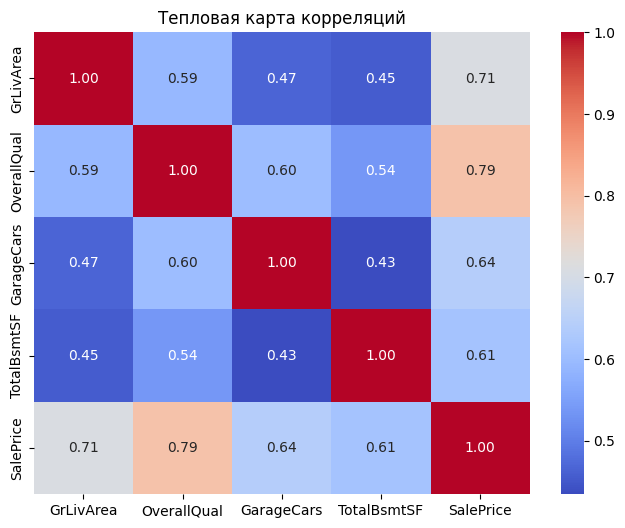

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Тепловая карта корреляций")
plt.show()

# Вариант 1. Простая линейная регрессия

## 5. Обучение модели

In [ ]:
X1 = data[['GrLivArea']]
y1 = data['SalePrice']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X1_train, y1_train)

print("Коэффициент:", model_simple.coef_[0])
print("Свободный член:", model_simple.intercept_)

Коэффициент: 102.48895891672333
Свободный член: 24899.74815733818


## 6. Прогнозы модели

In [ ]:
y1_pred = model_simple.predict(X1_test)

print("Первые 10 прогнозов:")
print(y1_pred[:10])

print("\nПервые 10 реальных значений:")
print(y1_test.iloc[:10].values)

mae1 = mean_absolute_error(y1_test, y1_pred)
rmse1 = mean_squared_error(y1_test, y1_pred) ** 0.5
r21 = r2_score(y1_test, y1_pred)

print(f"\nMAE:  {mae1:.2f}")
print(f"RMSE: {rmse1:.2f}")
print(f"R2:   {r21:.4f}")

Первые 10 прогнозов:
[134357.9562804  293625.79843699 130258.39792373 195441.37579477
 190931.86160243  89467.79227487 225163.17388062 174123.67234009
  89467.79227487 167666.86792833]

Первые 10 реальных значений:
[154500 325000 115000 159000 315500  75500 311500 146000  84500 135500]

MAE:  38341.20
RMSE: 58471.76
R2:   0.5543


## 7. Графики выходных результатов

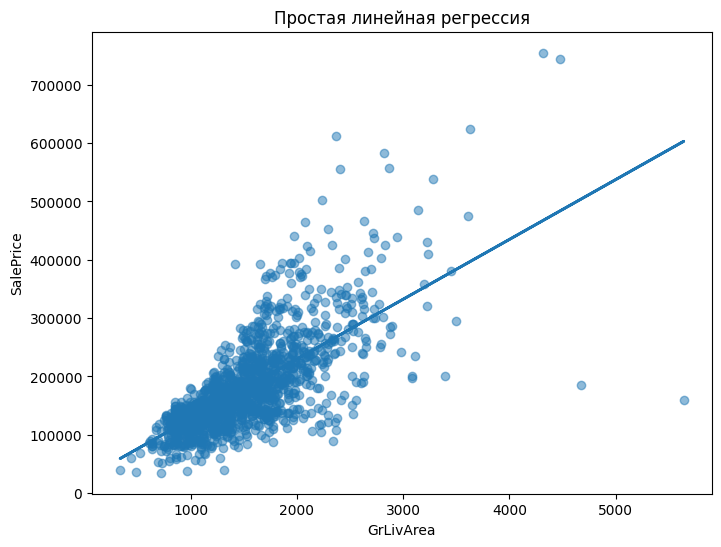

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X1, y1, alpha=0.5)
plt.plot(X1, model_simple.predict(X1), linewidth=2)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Простая линейная регрессия")
plt.show()

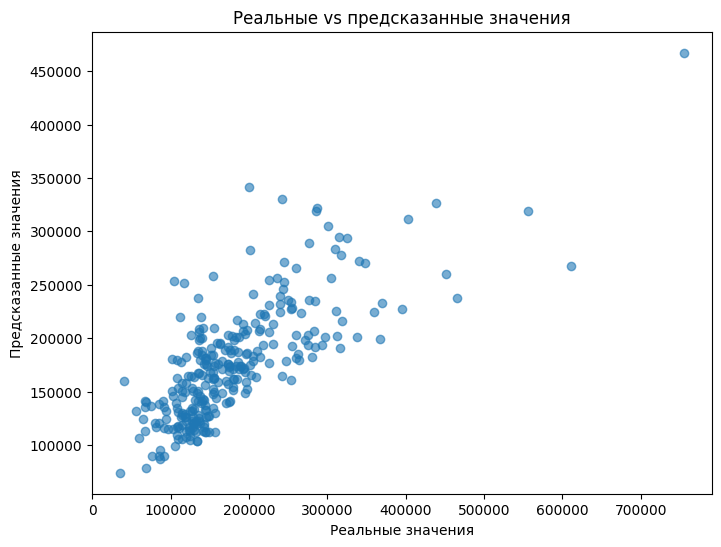

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y1_test, y1_pred, alpha=0.6)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Реальные vs предсказанные значения")
plt.show()

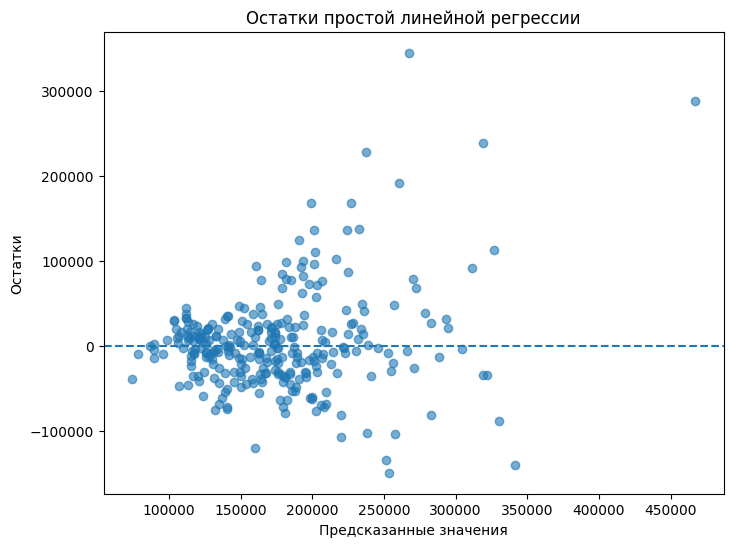

In [ ]:
residuals1 = y1_test - y1_pred

plt.figure(figsize=(8, 6))
plt.scatter(y1_pred, residuals1, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Остатки простой линейной регрессии")
plt.show()

# Вариант 2. Множественная линейная регрессия

## 8. Обучение модели

In [ ]:
X2 = data[['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF']]
y2 = data['SalePrice']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X2_train, y2_train)

print("Коэффициенты:")
for feature, coef in zip(X2.columns, model_multi.coef_):
    print(f"{feature}: {coef}")

print("\nСвободный член:", model_multi.intercept_)

Коэффициенты:
GrLivArea: 42.79630492234347
OverallQual: 23766.297562454434
GarageCars: 19560.815806901726
TotalBsmtSF: 28.403728263023506

Свободный член: -94422.1245122923


## 9. Прогнозы модели

In [ ]:
y2_pred = model_multi.predict(X2_test)

print("Первые 10 прогнозов:")
print(y2_pred[:10])

print("\nПервые 10 реальных значений:")
print(y2_test.iloc[:10].values)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = mean_squared_error(y2_test, y2_pred) ** 0.5
r22 = r2_score(y2_test, y2_pred)

print(f"\nMAE:  {mae2:.2f}")
print(f"RMSE: {rmse2:.2f}")
print(f"R2:   {r22:.4f}")

Первые 10 прогнозов:
[143522.47855694 288596.45355633 136156.55446308 187027.68704309
 293501.0547308   45499.08664431 217353.74501084 173893.90010805
  45499.08664431 126762.87412633]

Первые 10 реальных значений:
[154500 325000 115000 159000 315500  75500 311500 146000  84500 135500]

MAE:  25446.05
RMSE: 40036.42
R2:   0.7910


## 10. Графики выходных результатов

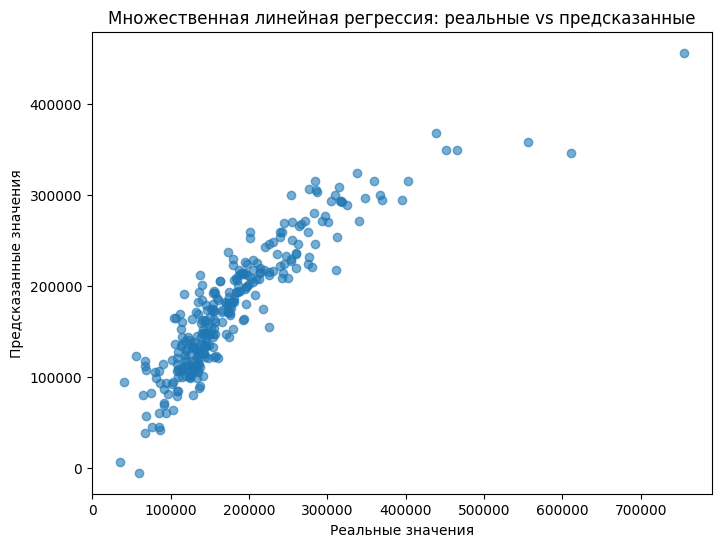

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, y2_pred, alpha=0.6)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Множественная линейная регрессия: реальные vs предсказанные")
plt.show()

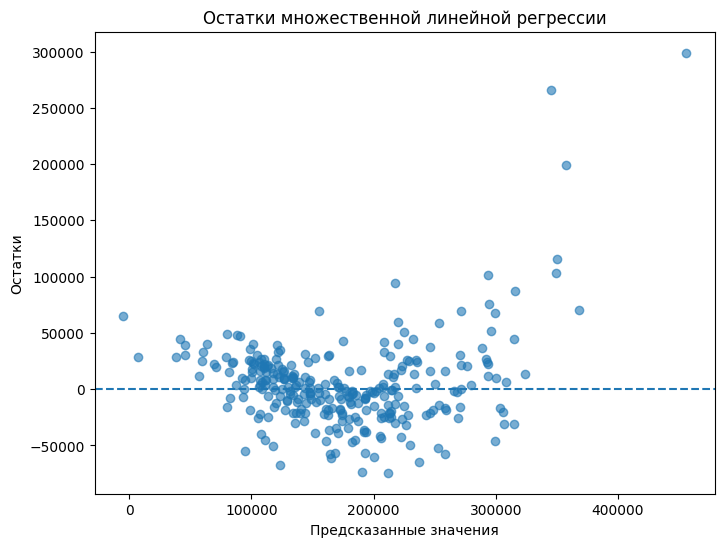

In [ ]:
residuals2 = y2_test - y2_pred

plt.figure(figsize=(8, 6))
plt.scatter(y2_pred, residuals2, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Остатки множественной линейной регрессии")
plt.show()

In [ ]:
metrics_comparison = pd.DataFrame({
    'Модель': ['Простая линейная регрессия', 'Множественная линейная регрессия'],
    'MAE': [mae1, mae2],
    'RMSE': [rmse1, rmse2],
    'R2': [r21, r22]
})

print(metrics_comparison)

                             Модель           MAE          RMSE        R2
0        Простая линейная регрессия  38341.204476  58471.756526  0.554263
1  Множественная линейная регрессия  25446.054739  40036.418664  0.791024


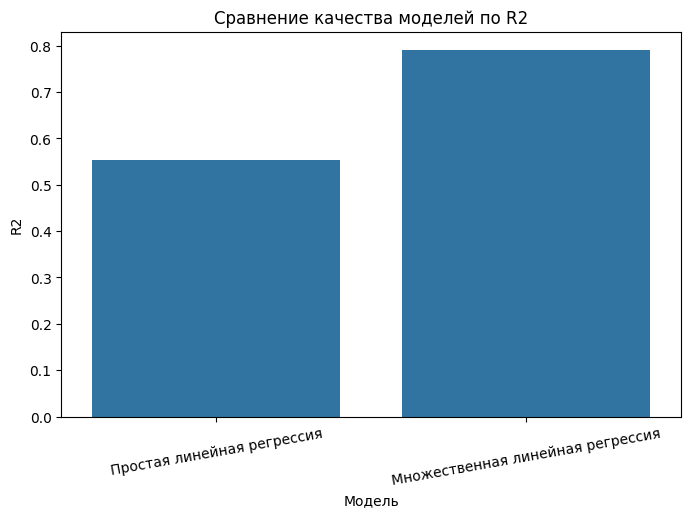

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_comparison, x='Модель', y='R2')
plt.title("Сравнение качества моделей по R2")
plt.xticks(rotation=10)
plt.show()